# Яндекс - кружок ИИ

## Занятие 2 - Линейная алгебра и numpy

**Домашнее задание**

**Требования к сдаче задания**
1. Задание необходимо выполнить в google colaboratory (закинуть тетрадку к себе на гугл-диск и открыть через google colab)
2. Для сдачи необходимо отправить **ссылку на тетрадку в колабе** преподавателю в ЛС в телеге либо сдать эту ссылку через google classroom
3. Перед сдачей работы **обязательно** убедиться, что у постороннего пользователя есть доступ к просмотру тетрадки! Оценка за работу, которую оказалось невозможно открыть по причине отсутствия доступов, будет снижена на 50%.
4. Для каждого задания внутри тетрадки есть конкретные критерии сдачи, за счет которых можно самостоятельно **предварительно** оценить свою работу

**Сроки сдачи работ**
1. Мягкий дедлайн: 1 неделя от выдачи задания (дополнительно фиксируется в сообщении от преподавателя в чате)
2. Жесткий дедлайн: 2 недели от выдачи задания. Все работы, уложившиеся в жесткий дедлайн, но сданные позже мягкого дедлайна, будут получать -0.5 балла за каждый просроченный день.

❗ Все задания нужно выполнять с минимально возможным количеством использования циклов `for`. Каждое использование цикла `for`, которого можно было избежать, снижает оценку за конкретное задание на 0.1 балла.

## Основы numpy

In [ ]:
import numpy as np

#### [1 балл] Для заданного массива `logits` выполните следующие действия:

1. Вычислите сигмоиду $\frac{1}{1+e^{-x}}$ для каждого из элементов. Форма массива должна сохраниться. Каждый элемент массива должен принимать значения от $0$ до $1$. Сохраните вычисления в массив `probas`.
2. Получите массив с предсказаниями `y_pred`, заменив каждое из чисел в массиве `probas` на $1$, если число больше порога $t$, или на $0$, если число меньше этого порога.

В данном задании запрещено использовать **готовые** функции из numpy, sklearn или pytorch, решающие поставленную задачу

In [ ]:
logits = np.array([-2.5, 3.2, -1.1, 0.5, -7, -3.8, 4.1, 3.9])
t = 0.6009

probas = 1 / (1 + np.exp(-logits))
y_pred = np.where(probas > t, 1, 0)

assert probas.shape == logits.shape
assert y_pred.shape == logits.shape

#### [1 балл] Для заданных массивов y_true и probas вычислите следующие функции:

1. MSE: $\frac{1}{N}\sum_{i=1}^N (p_i - y_i)^2$
2. RMSE: $\sqrt{\frac{1}{N}\sum_{i=1}^N (p_i - y_i)^2}$
3. BCE: $-\frac{1}{N}\sum_{i=1}^N y_i\times\log{p_i} + (1 - y_i)\times\log{(1-p_i)}$

В данном задании запрещено использовать **готовые** функции из numpy, sklearn или pytorch, решающие поставленную задачу

In [ ]:
y_true = np.array([0, 1, 0, 1, 0, 0, 1, 1])

mse = np.sum((probas - y_true)**2) / len(y_pred)
rmse = np.sqrt(mse)
bce = -np.sum(y_true * np.log(probas) + (1 - y_true) * np.log(1 - probas)) / len(y_pred)

#### [1 балл] Для массивов y_true, y_pred и probas выполните следующие действия:

1. Напишите функцию `accuracy(y_true, y_pred)`, вычисляющую *долю* значений в `y_pred`, совпавших с `y_true`
2. Выберите такой порог $t$, превращающий `probas` в `y_pred`, чтобы значение `accuracy` было максимальным. Эту задачу можно решить перебором, главное - постараться не использовать циклы!

В данном задании запрещено использовать **готовые** функции из numpy, sklearn или pytorch, решающие поставленную задачу

In [ ]:
def accuracy(true: np.ndarray, pred: np.ndarray):
    return np.sum(true == pred) / len(true)

best_t = np.linspace(0, 1, 30)
probas_all = 1 / (1 + np.exp(-logits))
predict_all = (probas_all[:, np.newaxis] > best_t).astype(int)
best_t = best_t[np.argmax(np.sum(predict_all == y_true[:, np.newaxis], axis=0))]
best_t # 0.27586206896551724

np.float64(0.27586206896551724)

#### [2 балла] Для массивов y_true и logits выполните следующие действия

1. Вычислите функцию softmax для каждой строки в матрице `logits`. Исходная форма матрицы `logits`: $(N, C)$. Конечная требуемая форма этой матрицы: $(N, C)$. Функция softmax для элемента $i$ в строке $l$ задаётся следующим выражением: $$softmax(l_i) = \frac{e^{l_i - max(l)}}{\sum_{i=1}^C e^{l_i - max(l)}}$$
2. Используя полученные значения, вычислите кросс-энтропию для **каждого объекта** в списке: $$CE_{i}=-\sum_{j=1}^C y_{i,j}\times\log{p_{i,j}}$$

In [ ]:
y_true = np.array([
    [0, 1, 0],
    [1, 0, 0],
    [1, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
])

logits = np.array([
    [-1, 0, 1],
    [3, -1, -2],
    [1, 0.5, 0],
    [-4, -2, -1],
    [0.1, 2, -0.1],
    [12, 11, 10],
    [90, 100, 110],
    [-200, 100, -100],
])

softmax_probas = np.exp(logits - np.max(logits, axis=1, keepdims=True)) / np.sum(np.exp(logits - np.max(logits, axis=1, keepdims=True)), axis=1, keepdims=True)
cross_entropy = -np.sum(y_true * np.log(softmax_probas), axis=1)

assert softmax_probas.shape == logits.shape
assert cross_entropy.shape == (logits.shape[0],)

In [ ]:
softmax_probas

array([[9.00305732e-002, 2.44728471e-001, 6.65240956e-001],
       [9.75558755e-001, 1.78679819e-002, 6.57326319e-003],
       [5.06480391e-001, 3.07195886e-001, 1.86323723e-001],
       [3.51190270e-002, 2.59496460e-001, 7.05384513e-001],
       [1.17583077e-001, 7.86148042e-001, 9.62688813e-002],
       [6.65240956e-001, 2.44728471e-001, 9.00305732e-002],
       [2.06106005e-009, 4.53978686e-005, 9.99954600e-001],
       [5.14820022e-131, 1.00000000e+000, 1.38389653e-087]])

In [ ]:
cross_entropy

array([ 1.40760596e+00,  2.47448901e-02,  6.80269671e-01,  3.49012217e-01,
        2.40610156e-01,  4.07605964e-01,  4.54009603e-05, -0.00000000e+00])

## Основы линейной алгебры

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
x = np.linspace(-3, 3, 19)
y = np.linspace(-3, 3, 19)
X, Y = np.meshgrid(x, y)
points = np.column_stack([X.ravel(), Y.ravel()])

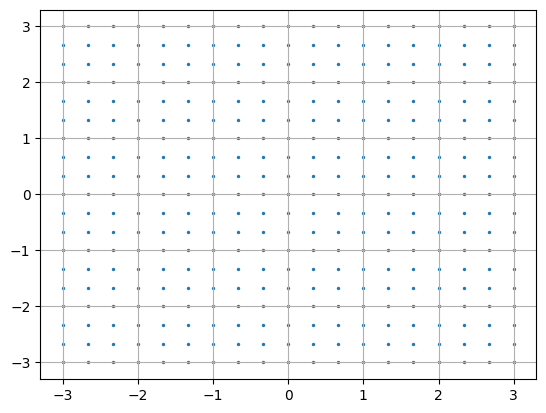

In [ ]:
plt.scatter(points[:, 0], points[:, 1], s=2)
plt.grid(True)
plt.show()

#### [1 балл] Подберите матрицы для следующих операций и визуализируйте эти операции:

1. Растягивание всех точек вдоль оси X в 2 раза с сохранением пропорций по Y
2. Сжатие всех точек вдоль оси Y в 2 раза с сохранением пропорций по Y
3. Одновременное растягивание всех точек вдоль оси X в 1.337 раза и сжатие всех точек вдоль оси Y в 0.6569 раза

In [ ]:
stretch_op = np.array([[2, 0],
              [0, 1]])
squeeze_op = np.array([[1, 0],
              [0, 0.5]])
stretch_squeeze_op = np.array([[1.337, 0],
                      [0, 0.6569]])

In [ ]:
stretch_points = points @ stretch_op
squeeze_points = points @ squeeze_op
stretch_squeeze_points = points @ stretch_squeeze_op

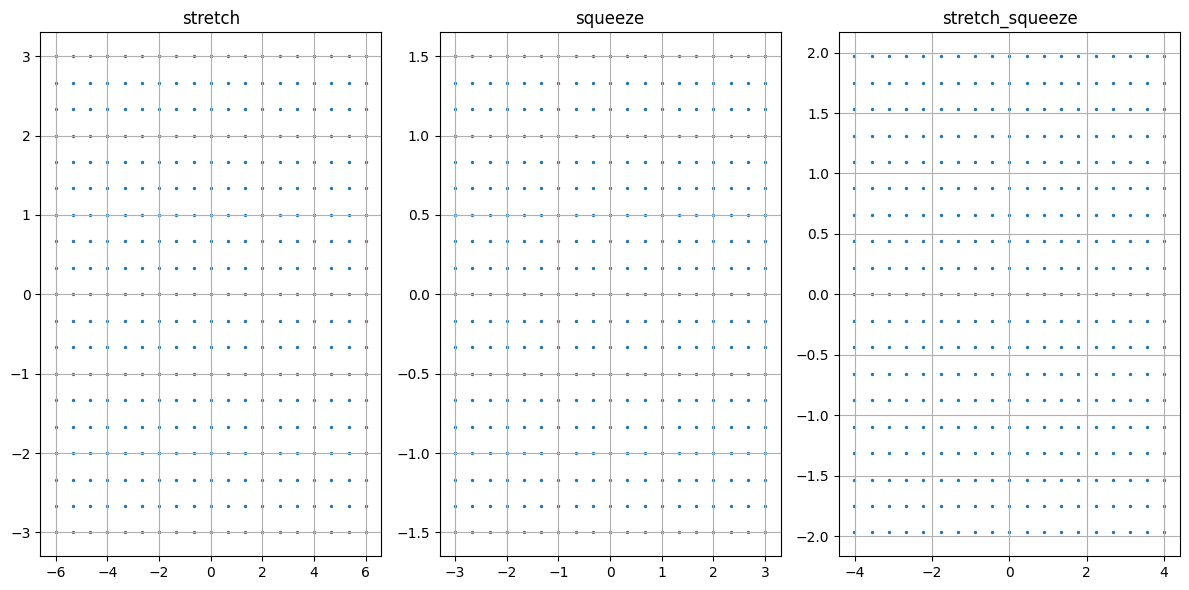

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
axs = axs.flatten()
axs[0].scatter(stretch_points[:, 0], stretch_points[:, 1], s=2)
axs[1].scatter(squeeze_points[:, 0], squeeze_points[:, 1], s=2)
axs[2].scatter(stretch_squeeze_points[:, 0], stretch_squeeze_points[:, 1], s=2)
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)
axs[0].set_title("stretch")
axs[1].set_title("squeeze")
axs[2].set_title("stretch_squeeze")
plt.tight_layout()
plt.show()

#### [1 балл] Найдите угол между векторами через скалярное произведение

1. Выберите произвольный угол $\alpha$ в радианах от $0$ до $\frac{\pi}{2}$
2. Задайте матрицу $\rho$ `=[[cos(a), -sin(a)], [sin(a), cos(a)]]`
3. Умножьте заданный вектор-столбец на $\rho^T$
4. Воспользовавшись свойством скалярного произведения, найдите косинус угла между векторами

Какому углу соответствует значение найденного косинуса?

In [ ]:
from numpy import cos, sin
theta = np.pi / 3

x = np.array([[1, 5]])
r = np.array([
    [cos(theta), -sin(theta)],
    [sin(theta), cos(theta)],
])

y = x @ r.T
scalar = (x @ y.T)[0][0] / np.linalg.norm(x) / np.linalg.norm(y)
print(np.arccos(scalar)) # соответсвует theta

1.0471975511965974


#### [1 балл] Исследуйте воздействие специальной матрицы на вектора

1. Возьмите специальную матрицу $A$ и исследуйте её действие на различные векторы: возьмите 10-20 случайных векторов, примените к ним матрицу A, выведите с помощью `plt.imshow` исходные и преобразованные векторы
2. Попробуйте применить матрицу $A$ к векторам (1,1), (1,-1), (1,0), (0,1), (1,2), (2,1). Для каждого вектора измерьте:
    1. Угол между исходным и преобразованным вектором
    2. Отношение длин $\frac{|Av|}{|v|}$
3. Зафиксируйте закономерность:
   - Есть ли направления, где векторы не поворачиваются?
   - Что происходит с длинами в этих направлениях?
   - Запишите найденные "секретные направления" и коэффициенты растяжения

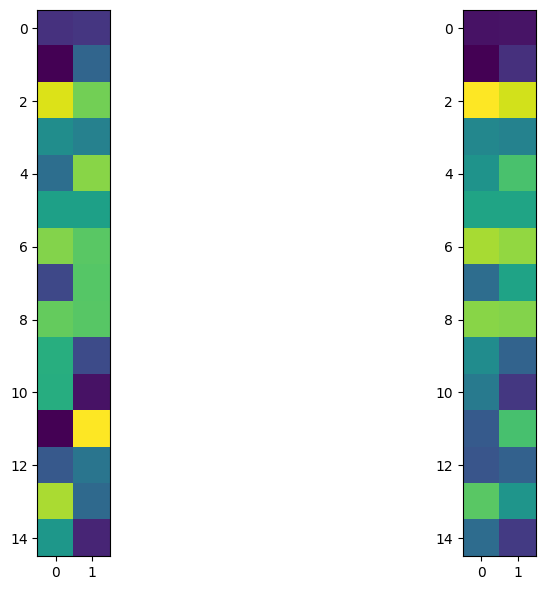

In [ ]:
A = np.array([[2, 1],
              [1, 2]])

vec = np.random.rand(15, 2)
vec_a = vec @ A.T

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.flatten()
axs[0].imshow(vec)
axs[1].imshow(vec_a)
plt.tight_layout()
plt.show()

In [ ]:
vecs = np.array([
    [1, 1],
    [1, -1],
    [1, 0],
    [0, 1],
    [1, 2],
    [2, 1]
])

el_a = vecs @ A.T
scalar = np.sum(vecs * el_a, axis=1) / np.linalg.norm(vecs, axis=1) / np.linalg.norm(el_a, axis=1)
print(*np.degrees(np.arccos(scalar)))
print(*np.linalg.norm(el_a, axis=1) / np.linalg.norm(vecs, axis=1))

0.0 8.537736462515939e-07 26.565051177077994 26.565051177077994 12.094757077012089 12.094757077012089
2.9999999999999996 1.0 2.23606797749979 2.23606797749979 2.8635642126552705 2.8635642126552705


1) Для вектора (1, 1) и (1, -1) (8.537736462515939e-07 это погрешность округляем до 0) направление не поменялось.
2) Для вектора (1, 1) растянули в 3 раза в этом направлении, а длина вектора (1, -1) не изменилась
3) Все векторы для которых y = x растягивает в 3 раза, все векторы для которых y = -x отсавляет не изменными

#### [2 балла] Поэкспериментируйте с поворотом изображения

1. Загрузите датасет MNIST, выберите какую-нибудь картинку и трансформируйте её в `(28, 28)`
2. Создайте координатную сетку так, чтобы её центр находился в `(14,14)`
3. Создайте матрицу $\rho$ `=[[cos(a), -sin(a)], [sin(a), cos(a)]]` для какого-нибудь заранее выбранного угла $\alpha$
4. Создайте новую матрицу `result` размером `(28, 28)`
5. Выполните поворот двумя способами:
   1. Умножьте каждую координату из координатной сетки на матрицу $rot^T$, посчитав таким образом для каждой исходной ячейки координаты новой, а затем установите в каждую новую ячейку значение из исходной
   2. Вычислите обратную матрицу ${\rho^{-1}}$ и умножьте каждую координату из сетки на ${\rho^{-1}}^T$, посчитав таким образом для каждой новой ячейки координаты исходной, и установите во все новые ячейки значения из исходных координат

Видна ли разница между подходами? В чём именно отличие?

In [ ]:
from sklearn.datasets import fetch_openml
from math import cos, pi, sin

mnist = fetch_openml('mnist_784', as_frame=False)

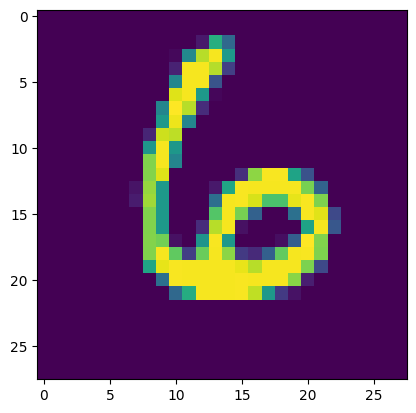

In [ ]:
plt.imshow(mnist.data[1488].reshape(28, -1))

In [ ]:
theta = np.pi / 3
img = mnist.data[1488].reshape(28, 28)
r = np.array([
    [cos(theta), -sin(theta)],
    [sin(theta), cos(theta)],
])
result = np.zeros_like(img)

In [ ]:
g = np.arange(28) - 14
X, Y = np.meshgrid(g, g)
points = np.column_stack([X.ravel(), Y.ravel()])
points_r = (points @ r.T).astype(int) + 14
mask = (points_r[:, 0] >= 0) & (points_r[:, 1] >= 0) & (points_r[:, 0] < 28) & (points_r[:, 1] < 28)
result[points_r[mask][:, 1], points_r[mask][:, 0]] = img.ravel()[mask]

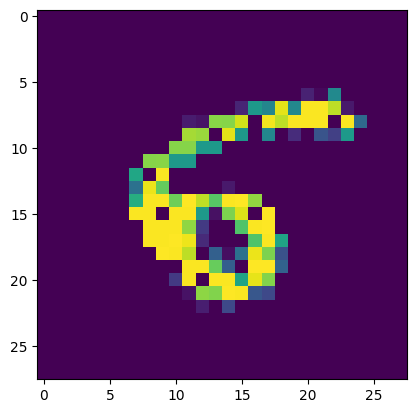

In [ ]:
plt.imshow(result)

In [ ]:
result1 = np.zeros_like(img)

In [ ]:
points_ri = (points @ np.linalg.inv(r).T).astype(int) + 14
mask = (points_ri[:, 0] >= 0) & (points_ri[:, 1] >= 0) & (points_ri[:, 0] < 28) & (points_ri[:, 1] < 28)
result1.ravel()[mask] = img[points_ri[mask][:, 1], points_ri[mask][:, 0]]

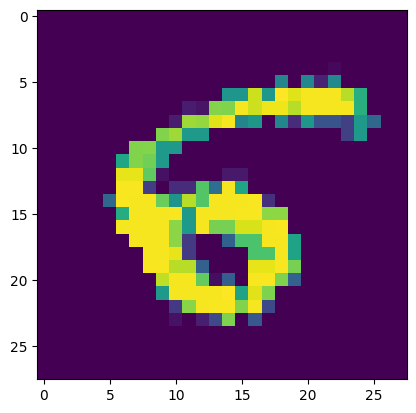

In [ ]:
plt.imshow(result1)

Второй способ выдаёт картинку без дефектов и более точного качества, чем первый